In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ORIGINAL_IMAGE = r"E:\JupyterProjects\test.png"

GEOMETRIC_IMAGE = (
    r"E:\JupyterProjects\tata_progressive_output"
    r"\img5_step5_final.png"
)

CURVE_OUTPUT_DIR = (
    r"E:\JupyterProjects\curve_progressive_output"
)

os.makedirs(
    CURVE_OUTPUT_DIR,
    exist_ok=True
)

print("Original exists :", os.path.exists(ORIGINAL_IMAGE))
print("Geometric exists:", os.path.exists(GEOMETRIC_IMAGE))

Original exists : True
Geometric exists: True


In [3]:
original_bgr = cv2.imread(ORIGINAL_IMAGE)
geometric_bgr = cv2.imread(GEOMETRIC_IMAGE)

if original_bgr is None:
    raise FileNotFoundError(ORIGINAL_IMAGE)

if geometric_bgr is None:
    raise FileNotFoundError(GEOMETRIC_IMAGE)

original_rgb = cv2.cvtColor(
    original_bgr,
    cv2.COLOR_BGR2RGB
)

geometric_rgb = cv2.cvtColor(
    geometric_bgr,
    cv2.COLOR_BGR2RGB
)

print("Original:", original_rgb.shape)
print("Geometric:", geometric_rgb.shape)

Original: (2048, 1152, 3)
Geometric: (2048, 1152, 3)


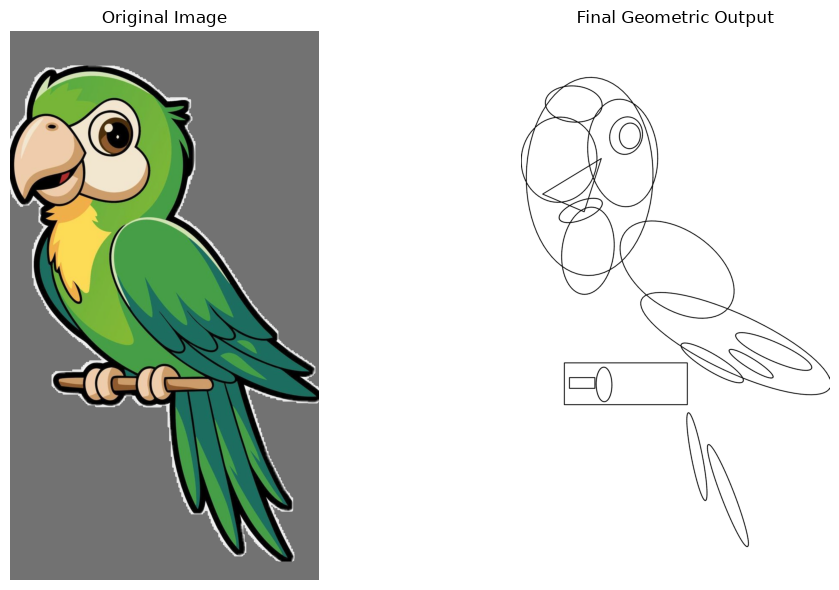

In [4]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(geometric_rgb)
plt.title("Final Geometric Output")
plt.axis("off")

plt.tight_layout()
plt.show()

Original edges extracted


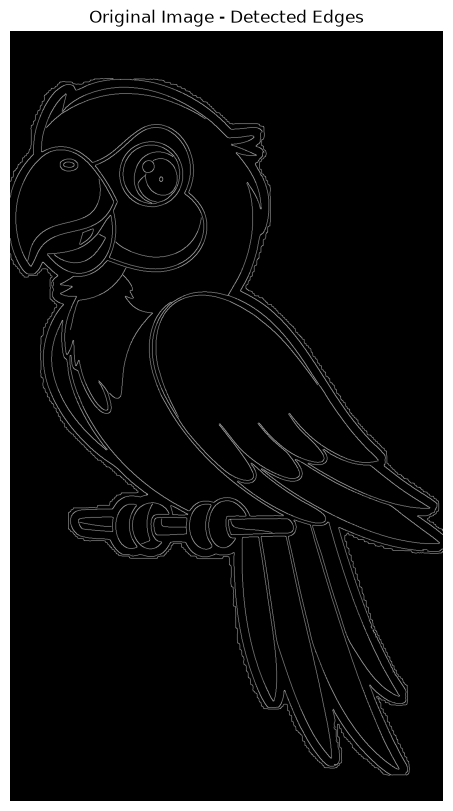

In [5]:
# ============================================================
# CURVE MODULE - STEP 1
# Extract line / curve information from original image
# ============================================================

gray = cv2.cvtColor(
    original_bgr,
    cv2.COLOR_BGR2GRAY
)

# Reduce small colour/noise variations
blurred = cv2.GaussianBlur(
    gray,
    (5, 5),
    0
)

# Detect edges
original_edges = cv2.Canny(
    blurred,
    50,
    150
)

print("Original edges extracted")

plt.figure(figsize=(8, 10))
plt.imshow(original_edges, cmap="gray")
plt.title("Original Image - Detected Edges")
plt.axis("off")
plt.show()

Geometric edges prepared


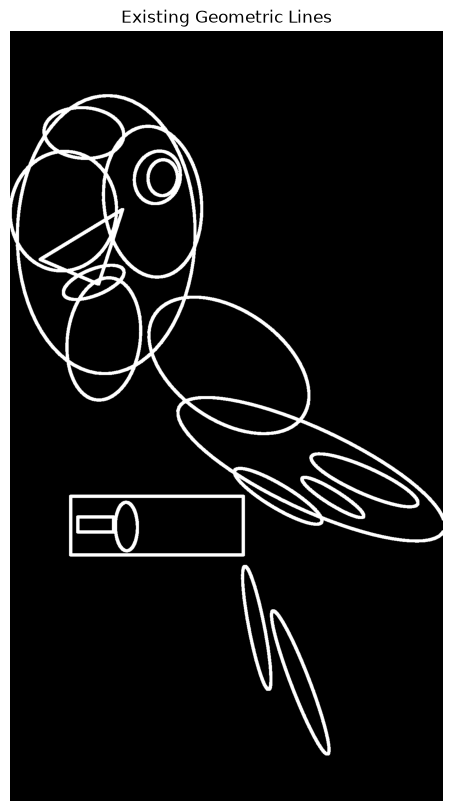

In [6]:
# ============================================================
# CURVE MODULE - STEP 2
# Detect lines already represented by geometric stage
# ============================================================

geo_gray = cv2.cvtColor(
    geometric_bgr,
    cv2.COLOR_BGR2GRAY
)

_, geometric_edges = cv2.threshold(
    geo_gray,
    220,
    255,
    cv2.THRESH_BINARY_INV
)

# Slightly widen geometric lines
kernel = np.ones(
    (5, 5),
    dtype=np.uint8
)

geometric_edges = cv2.dilate(
    geometric_edges,
    kernel,
    iterations=1
)

print("Geometric edges prepared")

plt.figure(figsize=(8, 10))
plt.imshow(geometric_edges, cmap="gray")
plt.title("Existing Geometric Lines")
plt.axis("off")
plt.show()

Candidate curves extracted


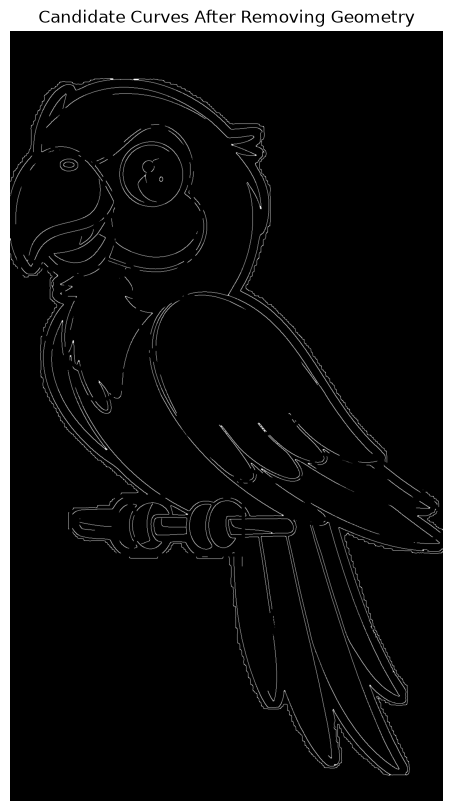

In [7]:
# ============================================================
# CURVE MODULE - STEP 3
# Remove lines already represented by geometric shapes
# ============================================================

# Ensure same size
if geometric_edges.shape != original_edges.shape:
    geometric_edges = cv2.resize(
        geometric_edges,
        (
            original_edges.shape[1],
            original_edges.shape[0]
        )
    )

remaining_curves = cv2.bitwise_and(
    original_edges,
    cv2.bitwise_not(geometric_edges)
)

# Remove tiny noise
curve_kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (3, 3)
)

remaining_curves = cv2.morphologyEx(
    remaining_curves,
    cv2.MORPH_CLOSE,
    curve_kernel,
    iterations=1
)

print("Candidate curves extracted")

plt.figure(figsize=(8, 10))
plt.imshow(remaining_curves, cmap="gray")
plt.title("Candidate Curves After Removing Geometry")
plt.axis("off")
plt.show()

In [8]:
# ============================================================
# NEW CELL 8
# Build meaningful curve components
# ============================================================

contours, hierarchy = cv2.findContours(
    remaining_curves,
    cv2.RETR_TREE,
    cv2.CHAIN_APPROX_NONE
)

H, W = remaining_curves.shape
IMG_AREA = H * W
IMG_DIAG = np.hypot(W, H)

curve_items = []

for i, cnt in enumerate(contours):

    if len(cnt) < 8:
        continue

    length = cv2.arcLength(cnt, False)
    area = abs(cv2.contourArea(cnt))

    x, y, w, h = cv2.boundingRect(cnt)

    bbox_area = w * h
    bbox_diag = np.hypot(w, h)

    if length < IMG_DIAG * 0.012:
        continue

    if bbox_diag < IMG_DIAG * 0.02:
        continue

    # Smooth a little
    eps = max(1.0, 0.0025 * length)

    smooth = cv2.approxPolyDP(
        cnt,
        eps,
        False
    )

    curve_items.append({
        "contour": smooth,
        "length": length,
        "area": area,
        "bbox": (x, y, w, h),
        "bbox_area": bbox_area,
        "bbox_diag": bbox_diag,
        "index": i
    })

print("Accepted curve components:", len(curve_items))

Accepted curve components: 104


In [9]:
# ============================================================
# NEW CELL 9
# Structural curve classification
# ============================================================

if not curve_items:
    raise RuntimeError("No curve components found.")

max_bbox = max(
    item["bbox_area"]
    for item in curve_items
)

max_length = max(
    item["length"]
    for item in curve_items
)

for item in curve_items:

    size_score = (
        item["bbox_area"] / max_bbox
        if max_bbox > 0 else 0
    )

    length_score = (
        item["length"] / max_length
        if max_length > 0 else 0
    )

    item["importance"] = (
        0.65 * size_score +
        0.35 * length_score
    )

curve_items.sort(
    key=lambda x: x["importance"],
    reverse=True
)

print("Curves ranked by structural importance.")

Curves ranked by structural importance.


In [15]:
# ============================================================
# NEW CELL 10
# Build a real outer silhouette for Step 1
# ============================================================

# Use original edge map to get the main outer object boundary
silhouette_source = original_edges.copy()

# Close small gaps so the main outline becomes connected
sil_kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (5, 5)
)

silhouette_source = cv2.morphologyEx(
    silhouette_source,
    cv2.MORPH_CLOSE,
    sil_kernel,
    iterations=2
)

sil_contours, _ = cv2.findContours(
    silhouette_source,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_NONE
)

if not sil_contours:
    raise RuntimeError("No silhouette contour found.")

# Largest external contour = main object silhouette
main_silhouette = max(
    sil_contours,
    key=cv2.contourArea
)

sil_length = cv2.arcLength(
    main_silhouette,
    True
)

silhouette_smooth = cv2.approxPolyDP(
    main_silhouette,
    0.0025 * sil_length,
    True
)

print("Main silhouette ready.")

Main silhouette ready.


In [16]:
# ============================================================
# NEW CELL 11
# Draw curve groups
# ============================================================

def draw_curve_items(items):

    canvas = np.ones(
        (H, W, 3),
        dtype=np.uint8
    ) * 255

    for item in items:

        cv2.polylines(
            canvas,
            [item["contour"]],
            False,
            (0, 0, 0),
            2,
            cv2.LINE_AA
        )

    return canvas

In [17]:
# ============================================================
# NEW CELL 12
# Build meaningful progressive curve stages
# ============================================================

def draw_items_with_optional_silhouette(
    items,
    include_silhouette=True
):

    canvas = np.ones(
        (H, W, 3),
        dtype=np.uint8
    ) * 255

    # Step base: full outer silhouette
    if include_silhouette:
        cv2.polylines(
            canvas,
            [silhouette_smooth],
            True,
            (0, 0, 0),
            2,
            cv2.LINE_AA
        )

    for item in items:
        cv2.polylines(
            canvas,
            [item["contour"]],
            False,
            (0, 0, 0),
            2,
            cv2.LINE_AA
        )

    return canvas


# Step 1 = silhouette only
curve_step1 = draw_items_with_optional_silhouette(
    []
)

# Step 2 = silhouette + largest internal/major curves
curve_step2 = draw_items_with_optional_silhouette(
    major_curves
)

# Step 3 = add important feature curves
curve_step3 = draw_items_with_optional_silhouette(
    major_curves
    + feature_curves
)

# Step 4 = add partial details
detail_split = max(
    1,
    int(len(detail_curves) * 0.55)
) if detail_curves else 0

curve_step4 = draw_items_with_optional_silhouette(
    major_curves
    + feature_curves
    + detail_curves[:detail_split]
)

# Step 5 = full accepted curve set
curve_step5 = draw_items_with_optional_silhouette(
    curve_items
)

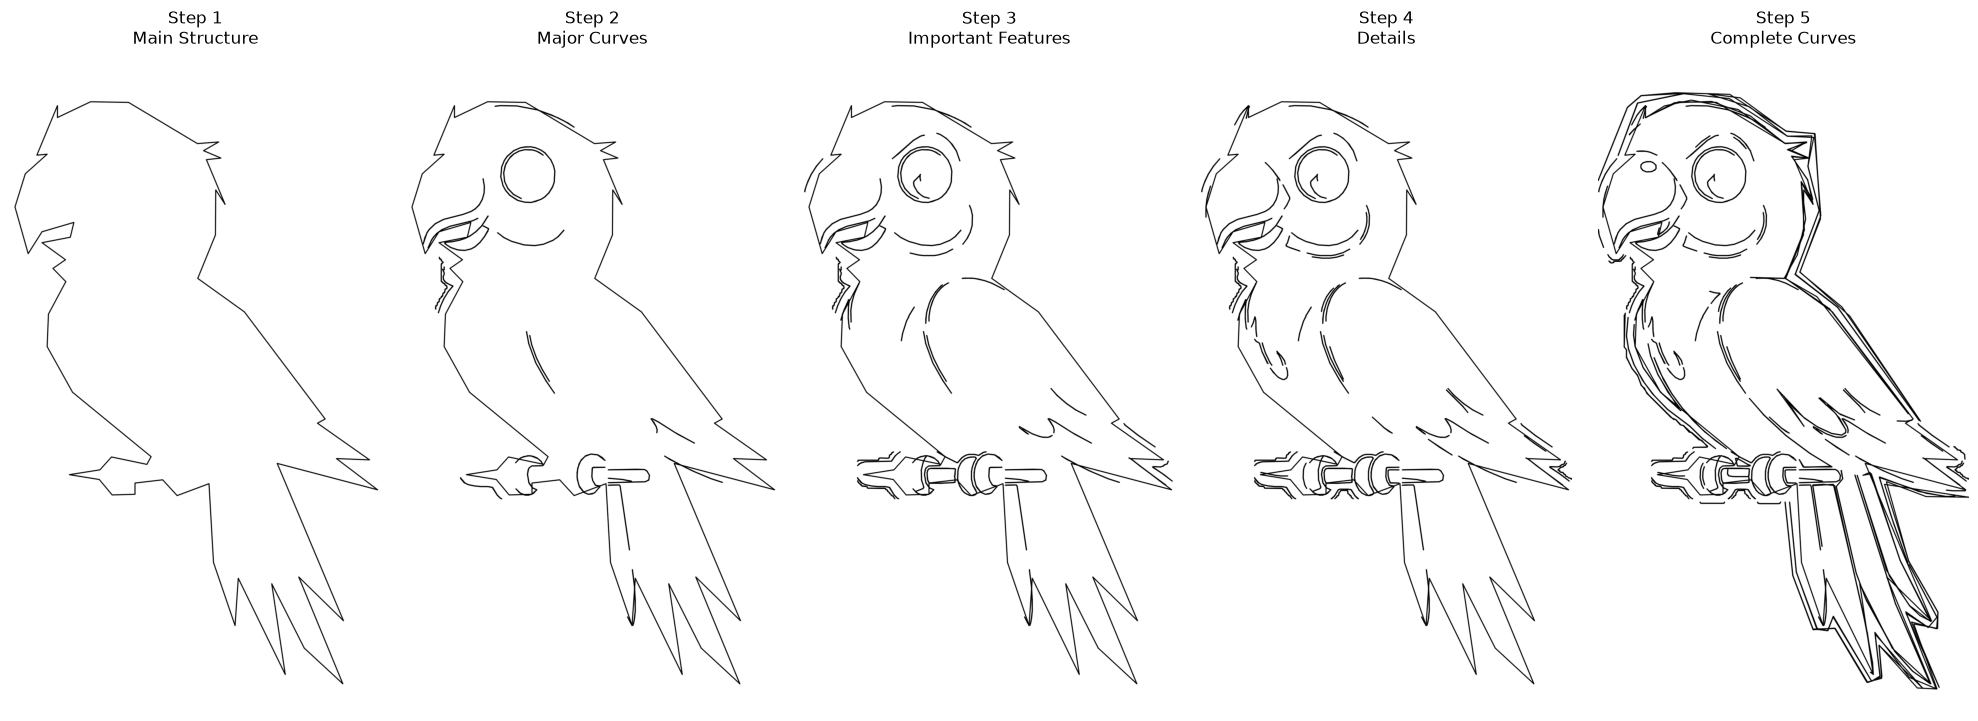

In [18]:
# ============================================================
# NEW CELL 13
# Preview
# ============================================================

images = [
    curve_step1,
    curve_step2,
    curve_step3,
    curve_step4,
    curve_step5
]

titles = [
    "Step 1\nMain Structure",
    "Step 2\nMajor Curves",
    "Step 3\nImportant Features",
    "Step 4\nDetails",
    "Step 5\nComplete Curves"
]

fig, axes = plt.subplots(
    1,
    5,
    figsize=(20, 7)
)

for ax, image, title in zip(
    axes,
    images,
    titles
):

    ax.imshow(
        cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )
    )

    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# NEW CELL 14
# Save outputs
# ============================================================

names = [
    "curve_step1_main.png",
    "curve_step2_major.png",
    "curve_step3_features.png",
    "curve_step4_details.png",
    "curve_step5_final.png"
]

for name, image in zip(
    names,
    images
):

    path = os.path.join(
        CURVE_OUTPUT_DIR,
        name
    )

    cv2.imwrite(
        path,
        image
    )

    print("Saved:", path)

Saved: E:\JupyterProjects\curve_progressive_output\curve_step1_main.png
Saved: E:\JupyterProjects\curve_progressive_output\curve_step2_major.png
Saved: E:\JupyterProjects\curve_progressive_output\curve_step3_features.png
Saved: E:\JupyterProjects\curve_progressive_output\curve_step4_details.png
Saved: E:\JupyterProjects\curve_progressive_output\curve_step5_final.png
